In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import sys, io
from pathlib import Path
from contextlib import redirect_stdout

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Project root op sys.path zetten
_root = Path.cwd().parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import config.settings      as _settings
import model.mip_model      as _mip_mod
import model.instance       as _inst_mod
import simulation.dispatcher as _disp_mod

from run_simulation import run_simulation
from utils.metrics  import compute_metrics

# ── Output-map ───────────────────────────────────────────────────────────────
CALIB_DIR = Path.cwd().parent / 'TimingStrategies_28_05'
CALIB_DIR.mkdir(parents=True, exist_ok=True)

# ── Experiment-instellingen ──────────────────────────────────────────────────
N_SEEDS   = 50
N_FREIGHT = 182

# ╔══════════════════════════════════════════════════════════════════════╗
# ║  TODO: vul in vóór uitvoeren                                         ║
# ╚══════════════════════════════════════════════════════════════════════╝
MC_DELAY_PER_TRAIN        = 120    # TODO: pas aan na MC-calibratie
MIN_OBJECTIVE_IMPROVEMENT = 60.0    # TODO: pas aan na MOI-calibratie

# ── Vaste parameters (beste waarden uit eerdere calibratie) ─────────────────
# Pas aan indien je andere referentiewaarden hebt.
FIXED_SETTINGS = dict(
    RESCHEDULING_HORIZON    = 3600,
    CONFLICT_WINDOW         = 1200,
    RETRACK_CONFLICT_WINDOW = 900,
    SWITCH_PENALTY          = 120.0,
)

# ── Basisconfig (geldt voor elke run, tenzij overschreven) ───────────────────
BASE_CFG = dict(
    n_freight             = N_FREIGHT,
    objective_strategy    = 'static',
    weight_passenger      = 1,
    weight_freight        = 1,
    upgrade_weight        = 0,       # 0 = niet actief bij static
    queue_mode            = 'fsfs',
    use_retracking        = True,
    save                  = False,
    mc_delay_per_train    = MC_DELAY_PER_TRAIN,
    min_objective_improvement = MIN_OBJECTIVE_IMPROVEMENT,
)

sns.set_theme(style='whitegrid', palette='muted')
print(f'Output-map : {CALIB_DIR}')
print(f'Seeds      : {N_SEEDS}')
print(f'MC_delay   : {MC_DELAY_PER_TRAIN}s  (TODO als niet ingevuld)')
print(f'MOI        : {MIN_OBJECTIVE_IMPROVEMENT}s (TODO als niet ingevuld)')
print(f'Vaste instellingen: {FIXED_SETTINGS}')


Output-map : /Users/ddw/Desktop/Rescheduling/TimingStrategies_28_05
Seeds      : 50
MC_delay   : 120s  (TODO als niet ingevuld)
MOI        : 60.0s (TODO als niet ingevuld)
Vaste instellingen: {'RESCHEDULING_HORIZON': 3600, 'CONFLICT_WINDOW': 1200, 'RETRACK_CONFLICT_WINDOW': 900, 'SWITCH_PENALTY': 120.0}


In [2]:
# ── Settings monkey-patching ──────────────────────────────────────────────────
_PATCH_TARGETS = {
    'RESCHEDULING_HORIZON':    [_settings, _inst_mod],
    'CONFLICT_WINDOW':         [_settings, _inst_mod, _mip_mod],
    'RETRACK_CONFLICT_WINDOW': [_settings, _mip_mod],
    'SWITCH_PENALTY':          [_settings, _mip_mod],
}
_originals: dict = {}

def patch_settings(**kwargs):
    for attr, val in kwargs.items():
        targets = _PATCH_TARGETS.get(attr, [_settings])
        for mod in targets:
            if attr not in _originals:
                _originals[attr] = getattr(_settings, attr)
            setattr(mod, attr, val)

def restore_settings():
    for attr, orig in _originals.items():
        for mod in _PATCH_TARGETS.get(attr, [_settings]):
            setattr(mod, attr, orig)
    _originals.clear()

# ── run_batch ──────────────────────────────────────────────────────────────────
def run_batch(
    run_kwargs:      dict,
    label:           str,
    checkpoint_csv:  'Path | None' = None,
    n_seeds:         int = N_SEEDS,
    verbose:         bool = True,
) -> pd.DataFrame:
    """
    Voert n_seeds simulaties uit met gegeven run_kwargs.
    Slaat elke seed direct op naar checkpoint_csv (append).
    Bij herstart worden al gedane seeds overgeslagen.

    Parameters
    ----------
    run_kwargs      : volledige kwargs voor run_simulation (inclusief trigger-params)
    label           : unieke string die de config identificeert
    checkpoint_csv  : pad naar sectie-CSV; None = geen checkpoint
    """
    cfg = {**BASE_CFG, **run_kwargs}

    # ── Checkpoint: welke seeds zijn al gedaan? ──────────────────────────────
    existing_rows: list[dict] = []
    done_seeds:    set[int]   = set()
    _wrote_header = False

    if checkpoint_csv is not None and checkpoint_csv.exists():
        try:
            _ck = pd.read_csv(checkpoint_csv)
            _done = _ck[_ck['label'] == label].copy()
            if 'deadlock' in _done.columns:
                _done['deadlock'] = _done['deadlock'].astype(str).str.lower() == 'true'
            done_seeds    = set(_done['seed'].astype(int).tolist())
            existing_rows = _done.to_dict('records')
            _wrote_header = True          # bestand bestaat al → nooit opnieuw header
            if done_seeds:
                remaining = n_seeds - len(done_seeds)
                print(f'  [{label}] checkpoint: {len(done_seeds)}/{n_seeds} seeds klaar '
                      f'— nog {remaining} te gaan.')
        except Exception as e:
            print(f'  [{label}] checkpoint lezen mislukt ({e}) — opnieuw starten.')
            existing_rows, done_seeds, _wrote_header = [], set(), False
    elif checkpoint_csv is not None and not checkpoint_csv.exists():
        _wrote_header = False

    # ── Seeds draaien ────────────────────────────────────────────────────────
    new_rows: list[dict] = []

    for seed in range(n_seeds):
        if seed in done_seeds:
            continue

        patch_settings(**FIXED_SETTINGS)
        try:
            buf = io.StringIO()
            with redirect_stdout(buf):
                _, df, meta, _, _ = run_simulation(**cfg, seed=seed)
        finally:
            restore_settings()

        ctrl  = meta['controller_summary']
        m     = compute_metrics(df)
        total = max(1, ctrl.get('total_steps', 1))
        n_ev  = max(1, ctrl.get('n_evaluated', total))

        row = {
            'label':                    label,
            'seed':                     seed,
            # Trigger-identificatie
            'trigger_strategy':         cfg.get('trigger_strategy'),
            'event_driven_freq':        cfg.get('event_driven_freq'),
            'controller_freq':          cfg.get('controller_freq'),
            'periodic_freq':            cfg.get('periodic_freq'),
            'threshold_confidence':     cfg.get('threshold_confidence'),
            # Kwaliteitsmetrics
            'TED_combined':             m.get('TED_combined'),
            'TED_passenger':            m.get('TED_passenger'),
            'TED_freight':              m.get('TED_freight'),
            'delay_ratio':              m.get('delay_ratio'),
            'n_delay_gt3min':           m.get('n_delay_gt3min'),
            'n_delay_gt5min':           m.get('n_delay_gt5min'),
            'max_end_delay':            m.get('max_end_delay'),
            # Effort-metrics
            'n_rescheduled':            ctrl['n_rescheduled'],
            'n_evaluated':              ctrl.get('n_evaluated', 0),
            'n_skipped_no_improvement': ctrl.get('n_skipped_no_improvement', 0),
            'total_solve_time_s':       ctrl.get('total_solver_runtime_s', 0),
            'mean_solve_time_s':        (ctrl.get('total_solver_runtime_s', 0)
                                         / max(1, ctrl['n_rescheduled'])),
            'trigger_rate_pct':         ctrl['n_rescheduled'] / total * 100,
            'trigger_rate_mc_pct':      ctrl['n_rescheduled'] / n_ev  * 100,
            'n_platform_switches':      ctrl.get('n_platform_switches', 0),
            'n_fcfs_fallback':          ctrl.get('n_fcfs_fallback', 0),
            # Betrouwbaarheid
            'deadlock':                 meta.get('deadlock_detected', False),
        }
        new_rows.append(row)

        # ── Meteen wegschrijven naar CSV ─────────────────────────────────────
        if checkpoint_csv is not None:
            pd.DataFrame([row]).to_csv(
                checkpoint_csv,
                mode='a',
                header=not _wrote_header,
                index=False,
            )
            _wrote_header = True

        if verbose and (seed + 1) % 5 == 0:
            ted = m.get('TED_combined')
            ted_s = f'{ted:.0f}' if ted is not None else '?'
            dl_flag = ' ⚠DL' if row['deadlock'] else ''
            print(f'  [{label}] seed {seed+1:2d}/{n_seeds}  TED={ted_s}s{dl_flag}')

    df_out = pd.DataFrame(existing_rows + new_rows)
    n_dl = int(df_out['deadlock'].sum()) if len(df_out) else 0
    if n_dl:
        print(f'  ⚠  {n_dl}/{len(df_out)} rijen hadden een deadlock (geëxcludeerd uit analyse)!')
    return df_out


print('Helpers geladen.')


Helpers geladen.


In [3]:
# ── Outlier-metrics per configuratie ─────────────────────────────────────────
def outlier_stats(series: pd.Series) -> dict:
    """
    Berekent outlier-metrics voor een reeks TED-waarden (één config).

    Metrics
    -------
    p90, p95       — 90e/95e percentiel (staart van de verdeling)
    n_outliers     — seeds boven Q3 + 1.5*IQR  (Tukey-definitie)
    outlier_frac   — n_outliers / n_seeds
    outlier_sev    — mean(TED outliers) / median(TED alle seeds)
                     Hoe ver liggen de uitschieters boven de typische waarde?
    cv             — std / mean  (coëfficiënt van variatie, stabiliteitsmaat)
    """
    s = series.dropna()
    if len(s) == 0:
        return dict(p90=None, p95=None, n_outliers=0,
                    outlier_frac=None, outlier_sev=None, cv=None)
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr     = q3 - q1
    fence   = q3 + 1.5 * iqr
    outliers = s[s > fence]
    median   = s.median()
    mean     = s.mean()
    return dict(
        p90          = s.quantile(0.90),
        p95          = s.quantile(0.95),
        n_outliers   = int(len(outliers)),
        outlier_frac = len(outliers) / len(s),
        outlier_sev  = (outliers.mean() / median) if (len(outliers) > 0 and median > 0) else 1.0,
        cv           = (s.std() / mean) if mean > 0 else None,
    )


def compute_summary(df: pd.DataFrame, group_col: str = 'label') -> pd.DataFrame:
    """
    Aggregeert per config:
      - TED: mean, std, median, p90, p95, max
      - Outlier-metrics (via outlier_stats)
      - Effort: mean n_rescheduled, total_solve_time_s
      - Deadlock-rate
    """
    df_clean = df[~df['deadlock']].copy()

    rows = []
    for lbl, grp in df_clean.groupby(group_col):
        ted = grp['TED_combined'].dropna()
        o   = outlier_stats(ted)
        rows.append({
            'label':          lbl,
            'n_seeds':        len(grp),
            # Kwaliteit
            'TED_mean':       ted.mean(),
            'TED_std':        ted.std(),
            'TED_median':     ted.median(),
            'TED_max':        ted.max(),
            'TED_p90':        o['p90'],
            'TED_p95':        o['p95'],
            # Outliers
            'n_outliers':     o['n_outliers'],
            'outlier_frac':   o['outlier_frac'],
            'outlier_sev':    o['outlier_sev'],
            'cv':             o['cv'],
            # Vertraagde treinen (gemiddeld per seed)
            'n_gt3min_mean':  grp['n_delay_gt3min'].mean(),
            'n_gt5min_mean':  grp['n_delay_gt5min'].mean(),
            'max_delay_mean': grp['max_end_delay'].mean(),
            'max_delay_p95':  grp['max_end_delay'].quantile(0.95),
            # Effort
            'n_rescheduled_mean': grp['n_rescheduled'].mean(),
            'solve_time_mean':    grp['total_solve_time_s'].mean(),
            # Betrouwbaarheid
            'n_deadlocks':    int(df[df[group_col] == lbl]['deadlock'].sum()),
        })

    # Voeg config-metadata terug toe (trigger-params van eerste rij)
    meta_cols = ['trigger_strategy','event_driven_freq',
                 'controller_freq','periodic_freq','threshold_confidence']
    for r in rows:
        first = df[df[group_col] == r['label']].iloc[0]
        for c in meta_cols:
            r[c] = first.get(c)

    return pd.DataFrame(rows).sort_values('TED_mean').reset_index(drop=True)


print('Outlier-helpers geladen.')


Outlier-helpers geladen.


---
## Sectie 1 — Periodic trigger

**Doel:** baseline bepalen en periodiciteitseffect kwantificeren.

| Label | periodic_freq (s) | Interpretatie |
|---|---|---|
| P_100000 | 100 000 | Bijna-nooit reschedule — puur timetable |
| P_450    | 450     | Hoge frequentie |
| P_900    | 900     | 1×/kwartier |
| P_1800   | 1800    | 1×/halfuur |
| P_3600   | 3600    | 1×/uur |


In [4]:
print('=' * 60)
print('SECTIE 1: Periodic trigger')
print('=' * 60)

PERIODIC_FREQS  = [100000, 450, 900, 1800, 3600]
PERIODIC_LABELS = ['P_100000', 'P_450', 'P_900', 'P_1800', 'P_3600']
_s1_csv = CALIB_DIR / 's1_periodic.csv'
s1_parts = []

for pf, lbl in zip(PERIODIC_FREQS, PERIODIC_LABELS):
    print(f'\n--- periodic_freq={pf}s ---')
    batch = run_batch(
        run_kwargs={
            'trigger_strategy': 'periodic',
            'periodic_freq':    float(pf),
            # Dummy-waarden voor niet-gebruikte params (geen MC draait)
            'event_driven_freq':    float(pf),
            'controller_freq':      float(pf),
            'threshold_confidence': 0.6,
        },
        label=lbl,
        checkpoint_csv=_s1_csv,
    )
    batch['label'] = lbl
    s1_parts.append(batch)

df_s1 = pd.concat(s1_parts, ignore_index=True)
df_s1.to_csv(_s1_csv, index=False)
print(f'\nKlaar. {len(df_s1)} rijen — {_s1_csv.name}')


SECTIE 1: Periodic trigger

--- periodic_freq=100000s ---
  [P_100000] seed  5/50  TED=45190s
  [P_100000] seed 10/50  TED=49307s
  [P_100000] seed 15/50  TED=55462s
  [P_100000] seed 20/50  TED=44948s
  [P_100000] seed 25/50  TED=41891s
  [P_100000] seed 30/50  TED=44642s
  [P_100000] seed 35/50  TED=46454s
  [P_100000] seed 40/50  TED=42996s
  [P_100000] seed 45/50  TED=44718s
  [P_100000] seed 50/50  TED=47201s
  ⚠  2/50 rijen hadden een deadlock (geëxcludeerd uit analyse)!

--- periodic_freq=450s ---
  [P_450] seed  5/50  TED=39198s
  [P_450] seed 10/50  TED=38911s
  [P_450] seed 15/50  TED=42621s
  [P_450] seed 20/50  TED=41940s
  [P_450] seed 25/50  TED=38625s
  [P_450] seed 30/50  TED=47983s
  [P_450] seed 35/50  TED=38270s
  [P_450] seed 40/50  TED=42329s
  [P_450] seed 45/50  TED=39258s
  [P_450] seed 50/50  TED=37790s

--- periodic_freq=900s ---
  [P_900] seed  5/50  TED=39870s
  [P_900] seed 10/50  TED=40093s
  [P_900] seed 15/50  TED=42383s
  [P_900] seed 20/50  TED=42295s


,label,TED_mean,TED_std,TED_p90,TED_p95,n_outliers,outlier_sev,cv,n_gt3min_mean,n_gt5min_mean,max_delay_mean,max_delay_p95,n_rescheduled_mean,n_deadlocks
0,P_1800,40609.8,2395.0,43493.6,44856.2,0,1.0,0.1,54.2,10.6,914.4,1633.0,28.4,2
1,P_900,40700.1,2556.8,44654.2,45560.5,0,1.0,0.1,53.5,10.8,1025.1,1574.0,46.5,1
2,P_450,40765.8,2670.8,43906.8,45917.6,2,1.2,0.1,54.8,10.4,896.3,1585.6,86.5,0
3,P_3600,43009.9,2413.3,46087.5,46404.2,2,1.1,0.1,61.2,13.5,905.4,1633.0,20.1,2
4,P_100000,46876.7,3832.6,51373.8,53173.2,1,1.3,0.1,70.1,19.3,1015.8,1633.0,0.0,2


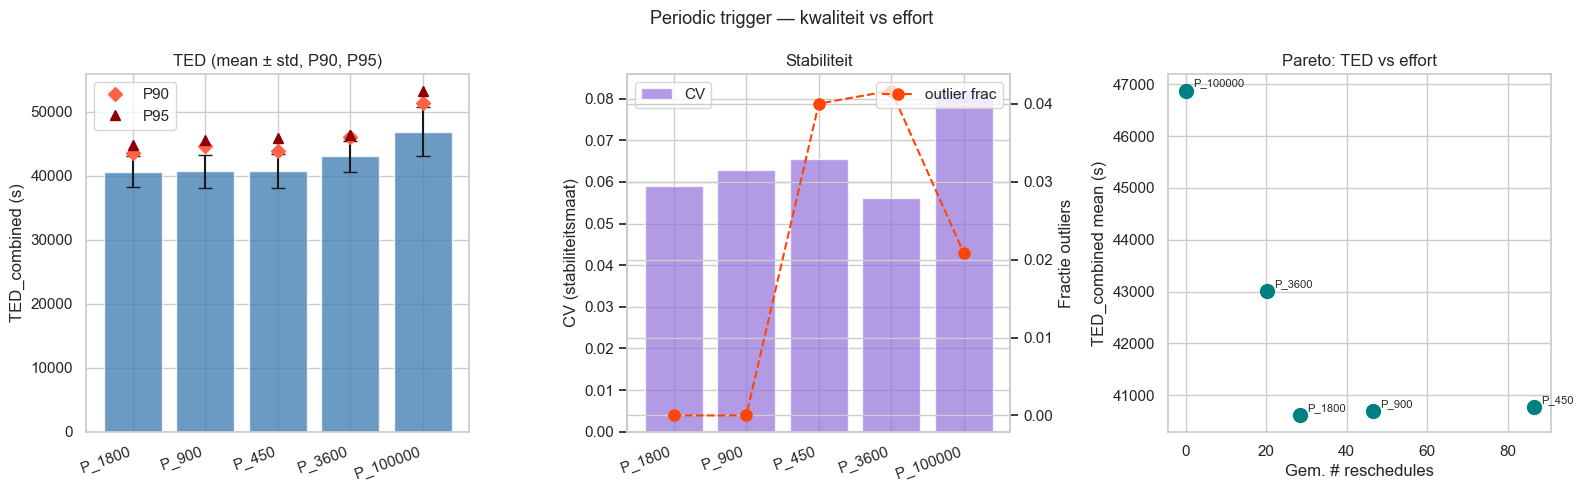

Opgeslagen: s1_periodic.png


In [5]:
# ── Analyse Sectie 1 ─────────────────────────────────────────────────────────
summary_s1 = compute_summary(df_s1)
display(summary_s1[['label','TED_mean','TED_std','TED_p90','TED_p95',
                     'n_outliers','outlier_sev','cv',
                     'n_gt3min_mean','n_gt5min_mean','max_delay_mean','max_delay_p95',
                     'n_rescheduled_mean','n_deadlocks']].round(1))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Periodic trigger — kwaliteit vs effort', fontsize=13)

lbls  = summary_s1['label']
x_pos = range(len(lbls))

# TED mean ± std
ax = axes[0]
ax.bar(x_pos, summary_s1['TED_mean'], yerr=summary_s1['TED_std'],
       capsize=5, color='steelblue', alpha=0.8)
ax.errorbar(x_pos, summary_s1['TED_p90'], fmt='D', color='tomato',
            ms=7, label='P90', zorder=5)
ax.errorbar(x_pos, summary_s1['TED_p95'], fmt='^', color='darkred',
            ms=7, label='P95', zorder=5)
ax.set_xticks(x_pos); ax.set_xticklabels(lbls, rotation=20, ha='right')
ax.set_ylabel('TED_combined (s)'); ax.set_title('TED (mean ± std, P90, P95)')
ax.legend()

# CV + outlier_frac
ax = axes[1]
ax2 = ax.twinx()
ax.bar(x_pos, summary_s1['cv'], color='mediumpurple', alpha=0.7, label='CV')
ax2.plot(x_pos, summary_s1['outlier_frac'], 'o--', color='orangered',
         ms=8, label='outlier frac')
ax.set_xticks(x_pos); ax.set_xticklabels(lbls, rotation=20, ha='right')
ax.set_ylabel('CV (stabiliteitsmaat)'); ax2.set_ylabel('Fractie outliers')
ax.set_title('Stabiliteit'); ax.legend(loc='upper left'); ax2.legend(loc='upper right')

# Pareto: TED vs n_rescheduled
ax = axes[2]
ax.scatter(summary_s1['n_rescheduled_mean'], summary_s1['TED_mean'],
           s=100, color='teal', zorder=5)
for _, r in summary_s1.iterrows():
    ax.annotate(r['label'], (r['n_rescheduled_mean'], r['TED_mean']),
                fontsize=8, textcoords='offset points', xytext=(5, 3))
ax.set_xlabel('Gem. # reschedules'); ax.set_ylabel('TED_combined mean (s)')
ax.set_title('Pareto: TED vs effort')

plt.tight_layout()
plt.savefig(CALIB_DIR / 's1_periodic.png', dpi=150)
plt.show()
print('Opgeslagen: s1_periodic.png')


---
## Sectie 2 — Event-driven trigger

Elke (event_driven_freq, controller_freq)-combinatie wordt getest
voor `threshold_confidence` ∈ {0.4, 0.8}.

**Labelformat:** `ED_{edf}_{cf}_c{conf×10:02d}`
Voorbeeld: `ED_900_450_c04` = edf=900s, cf=450s, conf=0.4


In [6]:
print('=' * 60)
print('SECTIE 2: Event-driven trigger')
print('=' * 60)

ED_COMBOS    = [(600, 300), (600, 600), (900, 450), (900, 900), (1800, 450), (1800, 900), (1800, 1800), (3600, 900), (3600, 1800), (3600, 3600), (5400, 1800), (5400, 3600), (5400, 5400)]
CONF_VALUES  = [0.4, 0.8]

_s2_csv = CALIB_DIR / 's2_event_driven.csv'
s2_parts = []

for (edf, cf) in ED_COMBOS:
    for conf in CONF_VALUES:
        lbl = f'ED_{edf}_{cf}_c{int(conf*10):02d}'
        print(f'\n--- ED {edf}:{cf}  conf={conf} ---')
        batch = run_batch(
            run_kwargs={
                'trigger_strategy':     'event_driven',
                'event_driven_freq':    float(edf),
                'controller_freq':      float(cf),
                'periodic_freq':        float(edf),   # niet gebruikt, consistentie
                'threshold_confidence': conf,
            },
            label=lbl,
            checkpoint_csv=_s2_csv,
        )
        s2_parts.append(batch)

df_s2 = pd.concat(s2_parts, ignore_index=True)
df_s2.to_csv(_s2_csv, index=False)
print(f'\nKlaar. {len(df_s2)} rijen — {_s2_csv.name}')


SECTIE 2: Event-driven trigger

--- ED 600:300  conf=0.4 ---
  [ED_600_300_c04] seed  5/50  TED=39887s
  [ED_600_300_c04] seed 10/50  TED=40517s
  [ED_600_300_c04] seed 15/50  TED=41382s
  [ED_600_300_c04] seed 20/50  TED=46264s
  [ED_600_300_c04] seed 25/50  TED=39121s
  [ED_600_300_c04] seed 30/50  TED=44678s
  [ED_600_300_c04] seed 35/50  TED=39332s
  [ED_600_300_c04] seed 40/50  TED=43614s
  [ED_600_300_c04] seed 45/50  TED=41806s
  [ED_600_300_c04] seed 50/50  TED=40015s

--- ED 600:300  conf=0.8 ---
  [ED_600_300_c08] seed  5/50  TED=39122s
  [ED_600_300_c08] seed 10/50  TED=39032s
  [ED_600_300_c08] seed 15/50  TED=42743s
  [ED_600_300_c08] seed 20/50  TED=40058s
  [ED_600_300_c08] seed 25/50  TED=40569s
  [ED_600_300_c08] seed 30/50  TED=35136s ⚠DL
  [ED_600_300_c08] seed 35/50  TED=38542s
  [ED_600_300_c08] seed 40/50  TED=41946s
  [ED_600_300_c08] seed 45/50  TED=41538s
  [ED_600_300_c08] seed 50/50  TED=39458s
  ⚠  2/50 rijen hadden een deadlock (geëxcludeerd uit analyse)!




=== threshold_confidence = 0.4 ===


,label,TED_mean,TED_std,TED_p90,TED_p95,n_outliers,outlier_sev,cv,n_gt3min_mean,n_gt5min_mean,max_delay_mean,max_delay_p95,n_rescheduled_mean,n_deadlocks
0,ED_900_450_c04,40417.4,2018.8,42722.7,43334.1,1,1.2,0.0,55.0,10.1,922.2,1586.0,39.7,1
1,ED_1800_450_c04,40758.8,2197.3,43665.2,44291.0,0,1.0,0.1,56.7,11.5,881.0,1615.4,26.0,0
3,ED_600_300_c04,41070.1,2266.2,43778.4,44556.2,0,1.0,0.1,55.0,10.7,980.2,1633.0,55.7,0
4,ED_900_900_c04,41196.7,2341.9,44522.4,45294.5,0,1.0,0.1,56.3,11.0,981.7,1633.0,36.5,1
9,ED_600_600_c04,41689.7,2167.6,44257.2,44866.4,0,1.0,0.1,57.2,11.5,998.1,1585.6,48.6,0
10,ED_1800_900_c04,41737.0,3178.3,46990.6,47964.0,6,1.2,0.1,56.9,11.2,963.7,1619.4,24.5,2
12,ED_3600_900_c04,42322.4,2704.6,46496.8,47260.0,4,1.2,0.1,57.5,12.4,971.2,1640.2,16.7,5
14,ED_1800_1800_c04,42823.9,2379.6,45290.0,46291.8,1,1.2,0.1,61.0,13.5,868.9,1621.3,19.3,3
15,ED_3600_1800_c04,43197.6,2643.7,45337.5,46736.1,1,1.2,0.1,62.6,13.5,899.5,1617.4,13.6,1
17,ED_5400_1800_c04,43727.9,2455.8,46735.1,47584.7,0,1.0,0.1,64.0,14.9,969.0,1662.9,10.6,2



=== threshold_confidence = 0.8 ===


,label,TED_mean,TED_std,TED_p90,TED_p95,n_outliers,outlier_sev,cv,n_gt3min_mean,n_gt5min_mean,max_delay_mean,max_delay_p95,n_rescheduled_mean,n_deadlocks
2,ED_600_300_c08,40899.0,2203.8,44126.2,44881.3,1,1.2,0.1,55.7,10.8,961.3,1633.0,49.2,2
5,ED_1800_450_c08,41219.5,2227.2,43813.8,44843.8,1,1.2,0.1,56.3,10.8,911.7,1585.0,25.1,0
6,ED_900_900_c08,41255.2,2303.1,44584.8,46081.9,4,1.1,0.1,57.2,10.8,941.9,1617.4,30.5,1
7,ED_1800_900_c08,41289.4,2987.3,46335.9,47214.3,2,1.2,0.1,56.1,10.6,940.2,1617.4,21.3,1
8,ED_900_450_c08,41558.1,2295.4,44829.2,46542.9,1,1.1,0.1,56.4,11.1,994.8,1633.0,35.0,1
11,ED_600_600_c08,41886.4,2359.2,44339.1,46145.0,2,1.1,0.1,56.9,12.0,893.8,1606.4,41.0,0
13,ED_3600_900_c08,42584.1,3065.4,45846.4,49638.3,4,1.2,0.1,59.9,13.1,898.5,1628.1,15.9,2
16,ED_3600_1800_c08,43633.3,2513.6,46947.7,48257.2,0,1.0,0.1,64.0,15.4,817.8,1572.5,11.6,4
18,ED_1800_1800_c08,44037.2,2797.6,47467.3,49792.3,2,1.2,0.1,63.5,14.8,990.2,1619.4,15.7,2
21,ED_5400_3600_c08,44290.1,2786.4,48718.5,49450.1,0,1.0,0.1,64.5,15.2,981.0,1633.0,9.2,2


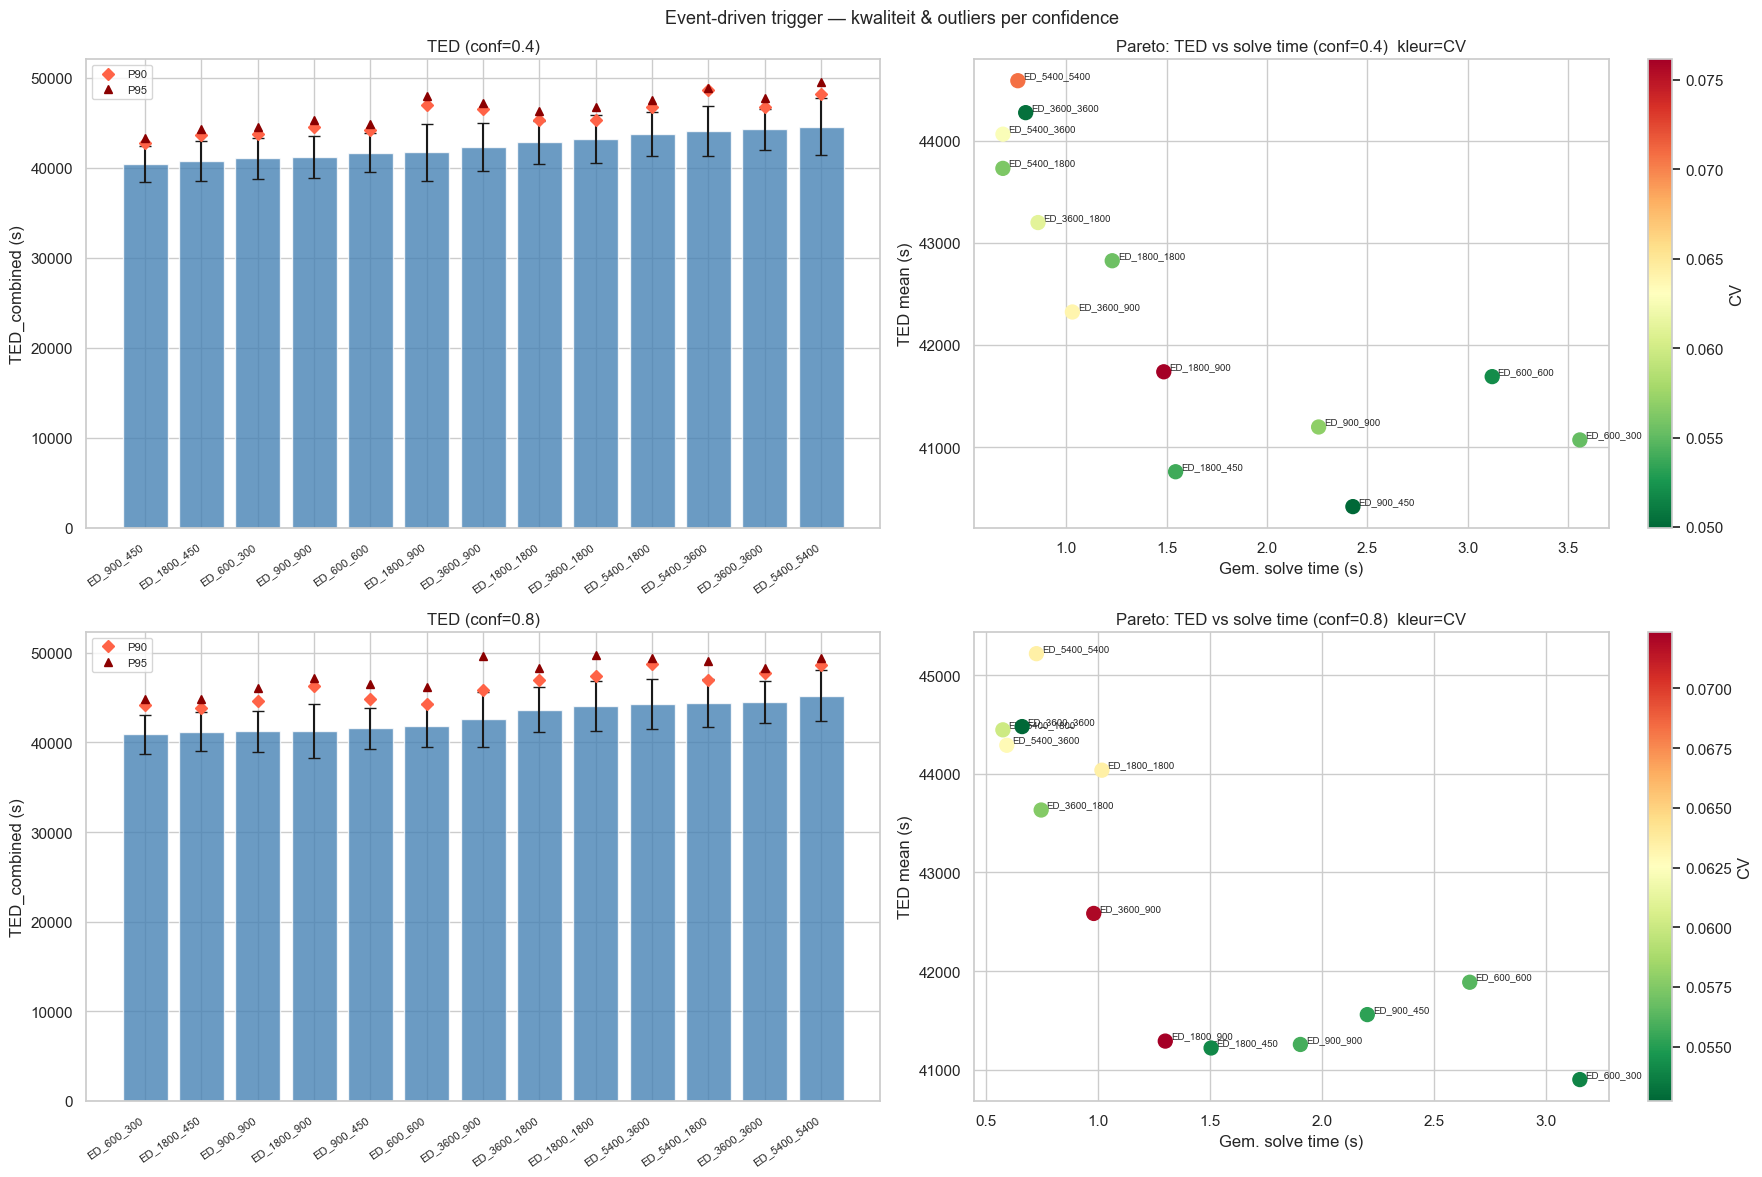

Opgeslagen: s2_event_driven.png


In [7]:
# ── Analyse Sectie 2 ─────────────────────────────────────────────────────────
summary_s2 = compute_summary(df_s2)

# Split per confidence-niveau voor leesbaarheid
for conf in [0.4, 0.8]:
    tag = f'c{int(conf*10):02d}'
    sub = summary_s2[summary_s2['label'].str.endswith(tag)].copy()
    print(f'\n=== threshold_confidence = {conf} ===')
    display(sub[['label','TED_mean','TED_std','TED_p90','TED_p95',
                  'n_outliers','outlier_sev','cv',
                  'n_gt3min_mean','n_gt5min_mean','max_delay_mean','max_delay_p95',
                  'n_rescheduled_mean','n_deadlocks']].round(1))

# ── Visualisatie ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Event-driven trigger — kwaliteit & outliers per confidence', fontsize=13)

for i, conf in enumerate([0.4, 0.8]):
    tag = f'c{int(conf*10):02d}'
    sub = summary_s2[summary_s2['label'].str.endswith(tag)].sort_values('TED_mean')
    lbls  = sub['label'].str.replace(f'_{tag}', '', regex=False)
    x_pos = range(len(lbls))

    # TED mean ± std + P90/P95
    ax = axes[i][0]
    ax.bar(x_pos, sub['TED_mean'], yerr=sub['TED_std'],
           capsize=4, color='steelblue', alpha=0.8)
    ax.errorbar(x_pos, sub['TED_p90'], fmt='D', color='tomato',  ms=6, label='P90')
    ax.errorbar(x_pos, sub['TED_p95'], fmt='^', color='darkred', ms=6, label='P95')
    ax.set_xticks(x_pos); ax.set_xticklabels(lbls, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('TED_combined (s)')
    ax.set_title(f'TED (conf={conf})')
    ax.legend(fontsize=8)

    # Pareto: TED vs solve_time
    ax = axes[i][1]
    sc = ax.scatter(sub['solve_time_mean'], sub['TED_mean'],
                    c=sub['cv'], cmap='RdYlGn_r', s=100, zorder=5)
    plt.colorbar(sc, ax=ax, label='CV')
    for _, r in sub.iterrows():
        short = r['label'].replace(f'_{tag}', '')
        ax.annotate(short, (r['solve_time_mean'], r['TED_mean']),
                    fontsize=7, textcoords='offset points', xytext=(4, 2))
    ax.set_xlabel('Gem. solve time (s)'); ax.set_ylabel('TED mean (s)')
    ax.set_title(f'Pareto: TED vs solve time (conf={conf})  kleur=CV')

plt.tight_layout()
plt.savefig(CALIB_DIR / 's2_event_driven.png', dpi=150)
plt.show()
print('Opgeslagen: s2_event_driven.png')


---
## Sectie 3 — Hybrid trigger

Combineert event-driven MC-trigger met een periodieke vangnet-trigger.

**Parameters per combo:** (event_driven_freq, controller_freq, periodic_freq)
**Labelformat:** `H_{edf}_{cf}_{pf}_c{conf×10:02d}`


In [ ]:
print('=' * 60)
print('SECTIE 3: Hybrid trigger')
print('=' * 60)

HYBRID_COMBOS = [(1800, 900, 3600), (1800, 900, 5400), (1800, 900, 7200), (3600, 900, 5400), (3600, 1800, 5400), (3600, 900, 7200), (3600, 1800, 7200), (5400, 900, 7200), (5400, 1800, 7200), (900, 450, 1800), (900, 450, 3600)]
CONF_VALUES   = [0.4, 0.8]

_s3_csv = CALIB_DIR / 's3_hybrid.csv'
s3_parts = []

for (edf, cf, pf) in HYBRID_COMBOS:
    for conf in CONF_VALUES:
        lbl = f'H_{edf}_{cf}_{pf}_c{int(conf*10):02d}'
        print(f'\n--- Hybrid edf={edf} cf={cf} pf={pf}  conf={conf} ---')
        batch = run_batch(
            run_kwargs={
                'trigger_strategy':     'hybrid',
                'event_driven_freq':    float(edf),
                'controller_freq':      float(cf),
                'periodic_freq':        float(pf),
                'threshold_confidence': conf,
            },
            label=lbl,
            checkpoint_csv=_s3_csv,
        )
        s3_parts.append(batch)

df_s3 = pd.concat(s3_parts, ignore_index=True)
df_s3.to_csv(_s3_csv, index=False)
print(f'\nKlaar. {len(df_s3)} rijen — {_s3_csv.name}')


SECTIE 3: Hybrid trigger

--- Hybrid edf=1800 cf=900 pf=3600  conf=0.4 ---
  [H_1800_900_3600_c04] seed  5/50  TED=38561s
  [H_1800_900_3600_c04] seed 10/50  TED=40683s
  [H_1800_900_3600_c04] seed 15/50  TED=39170s
  [H_1800_900_3600_c04] seed 20/50  TED=42348s
  [H_1800_900_3600_c04] seed 25/50  TED=39019s
  [H_1800_900_3600_c04] seed 30/50  TED=44990s
  [H_1800_900_3600_c04] seed 35/50  TED=38877s
  [H_1800_900_3600_c04] seed 40/50  TED=40927s
  [H_1800_900_3600_c04] seed 45/50  TED=40933s
  [H_1800_900_3600_c04] seed 50/50  TED=40898s

--- Hybrid edf=1800 cf=900 pf=3600  conf=0.8 ---
  [H_1800_900_3600_c08] seed  5/50  TED=41003s
  [H_1800_900_3600_c08] seed 10/50  TED=39189s
  [H_1800_900_3600_c08] seed 15/50  TED=39049s
  [H_1800_900_3600_c08] seed 20/50  TED=44949s
  [H_1800_900_3600_c08] seed 25/50  TED=39865s
  [H_1800_900_3600_c08] seed 30/50  TED=44654s
  [H_1800_900_3600_c08] seed 35/50  TED=43615s
  [H_1800_900_3600_c08] seed 40/50  TED=40607s
  [H_1800_900_3600_c08] seed 

In [ ]:
# ── Analyse Sectie 3 ─────────────────────────────────────────────────────────
summary_s3 = compute_summary(df_s3)

for conf in [0.4, 0.8]:
    tag = f'c{int(conf*10):02d}'
    sub = summary_s3[summary_s3['label'].str.endswith(tag)].copy()
    print(f'\n=== threshold_confidence = {conf} ===')
    display(sub[['label','TED_mean','TED_std','TED_p90','TED_p95',
                  'n_outliers','outlier_sev','cv',
                  'n_gt3min_mean','n_gt5min_mean','max_delay_mean','max_delay_p95',
                  'n_rescheduled_mean','n_deadlocks']].round(1))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Hybrid trigger — kwaliteit & outliers per confidence', fontsize=13)

for i, conf in enumerate([0.4, 0.8]):
    tag = f'c{int(conf*10):02d}'
    sub = summary_s3[summary_s3['label'].str.endswith(tag)].sort_values('TED_mean')
    lbls  = sub['label'].str.replace(f'_{tag}', '', regex=False)
    x_pos = range(len(lbls))

    ax = axes[i][0]
    ax.bar(x_pos, sub['TED_mean'], yerr=sub['TED_std'],
           capsize=4, color='mediumseagreen', alpha=0.8)
    ax.errorbar(x_pos, sub['TED_p90'], fmt='D', color='tomato',  ms=6, label='P90')
    ax.errorbar(x_pos, sub['TED_p95'], fmt='^', color='darkred', ms=6, label='P95')
    ax.set_xticks(x_pos); ax.set_xticklabels(lbls, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('TED_combined (s)')
    ax.set_title(f'TED (conf={conf})')
    ax.legend(fontsize=8)

    ax = axes[i][1]
    sc = ax.scatter(sub['n_rescheduled_mean'], sub['TED_mean'],
                    c=sub['cv'], cmap='RdYlGn_r', s=100, zorder=5)
    plt.colorbar(sc, ax=ax, label='CV')
    for _, r in sub.iterrows():
        short = r['label'].replace(f'_{tag}', '')
        ax.annotate(short, (r['n_rescheduled_mean'], r['TED_mean']),
                    fontsize=7, textcoords='offset points', xytext=(4, 2))
    ax.set_xlabel('Gem. # reschedules'); ax.set_ylabel('TED mean (s)')
    ax.set_title(f'Pareto: TED vs n_rescheduled (conf={conf})  kleur=CV')

plt.tight_layout()
plt.savefig(CALIB_DIR / 's3_hybrid.png', dpi=150)
plt.show()
print('Opgeslagen: s3_hybrid.png')


---
## Sectie 4 — Globale vergelijking: alle strategieën

Alle 53 configuraties naast elkaar:
- Top-N ranking op TED_mean
- Pareto-front TED vs effort
- Outlier-heatmap: welke configs zijn stabiel?


In [ ]:
# ── Samenvoegen ───────────────────────────────────────────────────────────────
# Herlaad vanuit CSV zodat de sectie onafhankelijk herstart kan worden.
def _load_csv(path):
    if path.exists():
        df = pd.read_csv(path)
        if 'deadlock' in df.columns:
            df['deadlock'] = df['deadlock'].astype(str).str.lower() == 'true'
        return df
    return pd.DataFrame()

df_all = pd.concat([
    _load_csv(CALIB_DIR / 's1_periodic.csv'),
    _load_csv(CALIB_DIR / 's2_event_driven.csv'),
    _load_csv(CALIB_DIR / 's3_hybrid.csv'),
], ignore_index=True)

print(f'Totaal: {len(df_all)} rijen, {df_all["label"].nunique()} configs, '
      f'{int(df_all["deadlock"].sum())} deadlocks')

summary_all = compute_summary(df_all)
summary_all['strategy_type'] = summary_all['trigger_strategy'].fillna('unknown')
summary_all.to_csv(CALIB_DIR / 'summary_all.csv', index=False)
print(f'Summary: {len(summary_all)} configs')


In [ ]:
# ── Top-20 ranking ────────────────────────────────────────────────────────────
top20 = summary_all.head(20)
print('\nTop-20 configuraties op TED_mean (excl. deadlocked seeds):')
display(top20[['label','strategy_type','TED_mean','TED_std','TED_p90','TED_p95',
               'n_outliers','outlier_sev','cv',
               'n_gt3min_mean','n_gt5min_mean','max_delay_mean','max_delay_p95',
               'n_rescheduled_mean','solve_time_mean','n_deadlocks']].round(2))


In [ ]:
# ── Staafdiagram: alle configs gesorteerd op TED_mean ─────────────────────────
fig, ax = plt.subplots(figsize=(22, 6))

colors = {'periodic': 'steelblue', 'event_driven': 'mediumseagreen', 'hybrid': 'salmon'}
bar_colors = [colors.get(s, 'gray') for s in summary_all['strategy_type']]

x = range(len(summary_all))
ax.bar(x, summary_all['TED_mean'], color=bar_colors, alpha=0.8,
       yerr=summary_all['TED_std'], capsize=2)
ax.errorbar(x, summary_all['TED_p90'], fmt='_', color='tomato', ms=6, lw=1.5, label='P90')
ax.errorbar(x, summary_all['TED_p95'], fmt='_', color='darkred', ms=6, lw=1.5, label='P95')

ax.set_xticks(list(x))
ax.set_xticklabels(summary_all['label'], rotation=70, ha='right', fontsize=7)
ax.set_ylabel('TED_combined (s)')
ax.set_title('Alle timing-strategieën gesorteerd op TED_mean (blauw=P, groen=ED, rood=H)')

from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=s) for s, c in colors.items()]
legend_handles += [
    plt.Line2D([0],[0], color='tomato', marker='_', ms=8, lw=0, label='P90'),
    plt.Line2D([0],[0], color='darkred', marker='_', ms=8, lw=0, label='P95'),
]
ax.legend(handles=legend_handles, fontsize=9)

plt.tight_layout()
plt.savefig(CALIB_DIR / 's4_all_TED_ranked.png', dpi=150)
plt.show()
print('Opgeslagen: s4_all_TED_ranked.png')


In [ ]:
# ── Pareto-plot: TED_mean vs n_rescheduled (kleur = CV) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, xcol, xlabel in zip(
    axes,
    ['n_rescheduled_mean', 'solve_time_mean'],
    ['Gem. # reschedules', 'Gem. totale solve time (s)'],
):
    sc = ax.scatter(
        summary_all[xcol],
        summary_all['TED_mean'],
        c=summary_all['cv'],
        cmap='RdYlGn_r',
        s=80,
        alpha=0.85,
        zorder=5,
    )
    plt.colorbar(sc, ax=ax, label='CV (instabiliteit)')

    for _, r in summary_all.iterrows():
        ax.annotate(r['label'], (r[xcol], r['TED_mean']),
                    fontsize=6, textcoords='offset points', xytext=(3, 2))

    ax.set_xlabel(xlabel)
    ax.set_ylabel('TED_combined mean (s)')
    ax.set_title(f'Pareto: TED vs {xlabel}\n(kleur = CV; groen = stabiel)')

plt.tight_layout()
plt.savefig(CALIB_DIR / 's4_pareto.png', dpi=150)
plt.show()
print('Opgeslagen: s4_pareto.png')


In [ ]:
# ── Outlier-heatmap ───────────────────────────────────────────────────────────
# Elke rij = één config; kolommen = outlier-metrics (genormaliseerd)
import warnings

pivot_data = summary_all.set_index('label')[
    ['cv', 'outlier_frac', 'outlier_sev', 'TED_p95']
].copy()

# Normaliseer per kolom zodat de heatmap vergelijkbaar is
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    pivot_norm = (pivot_data - pivot_data.min()) / (pivot_data.max() - pivot_data.min() + 1e-9)

fig, ax = plt.subplots(figsize=(10, max(8, len(pivot_norm) * 0.3)))
sns.heatmap(
    pivot_norm,
    cmap='RdYlGn_r',
    annot=pivot_data.round(2),
    fmt='.2f',
    linewidths=0.4,
    ax=ax,
    cbar_kws={'label': 'Genormaliseerde waarde (rood = slechtst)'},
)
ax.set_title('Outlier-profiel per configuratie (rood = instabiel/slechte staart)')
ax.set_xlabel('')

plt.tight_layout()
plt.savefig(CALIB_DIR / 's4_outlier_heatmap.png', dpi=150)
plt.show()
print('Opgeslagen: s4_outlier_heatmap.png')


In [ ]:
# ── Conclusie-tabel: Top-10 met TED én stabiliteitscriterium ─────────────────
# Filter eerst deadlock-vrije configs (n_deadlocks == 0)
safe = summary_all[summary_all['n_deadlocks'] == 0].copy()

# Samengestelde score: normaliseer TED_mean + cv (gelijke weging)
for col in ['TED_mean', 'cv']:
    safe[f'_{col}_norm'] = (safe[col] - safe[col].min()) / (safe[col].max() - safe[col].min() + 1e-9)
safe['score'] = safe['_TED_mean_norm'] + safe['_cv_norm']

top10 = safe.sort_values('score').head(10)
print('\nTop-10 op gecombineerde score (TED + stabiliteit, enkel deadlock-vrij):')
display(top10[['label','strategy_type','TED_mean','TED_std','TED_p95',
               'cv','n_outliers','outlier_sev',
               'n_gt3min_mean','n_gt5min_mean','max_delay_mean',
               'n_rescheduled_mean','n_deadlocks','score']].round(3))

top10.to_csv(CALIB_DIR / 'top10_timing_strategies.csv', index=False)
print('Opgeslagen: top10_timing_strategies.csv')
